# 12_时间序列分析方法-自回归滑动平均

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/global_air_quality_data_bj.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。
- 空气质量先按日期汇总重复记录、排序并补齐日频；仅向前填补缺口，再按时间划分训练和测试。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家详细的聊聊时间序列中的**自回归滑动平均**\~

**自回归滑动平均是什么？**

自回归滑动平均模型（ARMA）是一种常用于时间序列分析的方法，用来描述并预测基于历史数据的未来值。它包含了两个部分：

- **自回归（AR，AutoRegressive）部分**：基于之前的数值来预测当前的数值。简单来说，就是今天的值可以由前几天的值来预测。
- **滑动平均（MA，Moving Average）部分**：基于前几天的误差来预测当前的数值。也就是今天的值不仅依赖于之前的值，还会受到之前预测误差的影响。

ARMA 模型适用于**平稳**的时间序列数据，即数据的均值和方差基本保持不变，没有明显的趋势或周期。

### 案例：冰淇淋销售预测

假设我们是一家冰淇淋店的老板，想预测未来几天的冰淇淋销量。我们已知过去四天的冰淇淋销量（单位：个）为：

| 日期 | 销量 |
|-|-|
| 第1天 | 100 |
| 第2天 | 110 |
| 第3天 | 108 |
| 第4天 | 115 |

根据之前的销量数据，我们希望预测第5天的冰淇淋销量。

假设我们使用一个 ARMA(1,1) 模型（即 AR 部分取1阶，MA部分取1阶）进行预测。即，我们认为销量主要受前一天的销量及其误差影响。

用简单的数学模型表示为：


$$
Y_t = \phi Y_{t-1} + \theta \epsilon_{t-1} + \epsilon_t
$$


其中：

- $Y_t$是第 $t$天的销量。
- $\phi$是自回归部分的系数（与前一天销量的关系）。
- $\theta$是滑动平均部分的系数（与前一天误差的关系）。
- $\epsilon_t$是第 $t$天的随机误差，假设均值为0。

**步骤1：估计模型参数**

我们假设模型参数为 $\phi = 0.8$和 $\theta = 0.3$。这些参数可以通过更复杂的方法估计出来，但在这里我们直接给出，以便于理解。

**步骤2：预测第5天的销量**

我们知道：

- 第4天的销量 $Y_4 = 115$。
- 第4天预测值 $\hat{Y}_4$可以用公式预测（假设误差为0），例如前3天的销量为实际值。

计算第4天误差：  
$\epsilon_4 = Y_4 - \hat{Y}_4$  
第5天的预测值：  
$\hat{Y}_5 = \phi Y_4 + \theta \epsilon_4$

假设我们认为第4天没有预测误差（即实际等于预测值，所以误差为0），那么：  
$\epsilon_4 = 0$

那么，第5天的预测就变成了：  
$\hat{Y}_5 = 0.8 \times 115 + 0.3 \times 0$

让我们来计算这个结果。

**计算：**  
$\hat{Y}_5 = 0.8 \times 115 = 92 + 0 = 92$

因此，我们预测第5天的销量约为 **92个**冰淇淋。

**总结几点：**

1. **自回归**部分让我们根据过去的销量数据来预测未来销量。
2. **滑动平均**部分帮助我们使用过去的误差调整预测，使其更准确。
3. 在实际情况中，参数 $\phi$ 和 $\theta$ 可以通过历史数据来进行估计，以提高模型的准确性。

通过这个简单的例子，希望让大家对 ARMA 模型有了基本的了解。如果你需要进一步深入了解，可以尝试通过更多历史数据去拟合出更精确的 $\phi$ 和 $\theta$ 参数。

下面，咱们从原理方面，和大家详细解释\~

## 基本原理

### 1. ARMA(p, q) 模型定义

ARMA 模型由两个参数 $p$ 和 $q$ 定义：

- **p**：自回归部分的阶数，即前几期的值对当前值的影响。
- **q**：滑动平均部分的阶数，即前几期的误差对当前值的影响。

ARMA 模型的数学形式为：


$$
Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \sum_{j=1}^{q} \theta_j \epsilon_{t-j} + \epsilon_t
$$


其中：

- $Y_t$ 是时间 $t$ 的观测值。
- $c$ 是常数项。
- $\phi_i$ 是自回归部分的系数。
- $\theta_j$ 是滑动平均部分的系数。
- $\epsilon_t$ 是白噪声（随机误差），假设其均值为0，方差为$\sigma^2$。

### 2. AR部分推导（自回归模型）

自回归（AR）部分表示当前的观测值 $Y_t$ 由前 $p$ 个时刻的观测值通过线性组合得到。

假设我们有一个 $AR(p)$ 模型：


$$
Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \epsilon_t
$$


即：

- $Y_t$ 是当前的观测值；
- 它受 $p$ 个过去观测值的线性组合影响，系数为 $\phi_i$；
- $\epsilon_t$ 是随机误差（白噪声）。

### 3. MA部分推导（滑动平均模型）

滑动平均（MA）部分表示当前的观测值 $Y_t$ 由当前和前 $q$ 个时刻的误差通过线性组合得到。

假设我们有一个 $MA(q)$ 模型：


$$
Y_t = c + \epsilon_t + \sum_{j=1}^{q} \theta_j \epsilon_{t-j}
$$


即：

- $Y_t$ 是当前的观测值；
- 它由当前误差和前 $q$ 个时刻的误差线性组合得到；
- 系数为 $\theta_j$。

### 4. ARMA(p, q) 模型推导

ARMA 模型将上述两个模型结合。其公式可以写为：


$$
Y_t = c + \sum_{i=1}^{p} \phi_i Y_{t-i} + \epsilon_t + \sum_{j=1}^{q} \theta_j \epsilon_{t-j}
$$


推导过程如下：

1. **引入自回归**：将当前观测值 $Y_t$ 表示为过去 $p$ 个观测值的线性组合 $\sum_{i=1}^{p} \phi_i Y_{t-i}$，表示观测值的自相关性。
2. **引入滑动平均**：引入误差项 $\epsilon_t$ 以及过去 $q$ 个误差 $\sum_{j=1}^{q} \theta_j \epsilon_{t-j}$，表示当前观测值不仅受之前观测值的影响，也受到之前误差的影响。
3. **随机误差项**：添加 $\epsilon_t$ 表示观测值中不可预测的随机波动部分。

### 5. ARMA 模型参数估计

为了使用 ARMA 模型，我们需要估计 $\phi_i$ 和 $\theta_j$ 的参数值。通常的估计方法包括：

1. **自相关函数（ACF）和偏自相关函数（PACF）**：用于初步确定 $p$ 和 $q$ 的阶数。
2. **极大似然估计（MLE）**：通过最大化似然函数来估计模型参数。
3. **最小二乘法（OLS）**：通过最小化残差平方和来估计模型参数。

### 6. ARMA模型示例推导

假设我们要构建一个 ARMA(1,1) 模型，得到的方程为：


$$
Y_t = c + \phi Y_{t-1} + \epsilon_t + \theta \epsilon_{t-1}
$$


1. 我们观察到当前的值 $Y_t$ 依赖于前一个时刻的观测值 $Y_{t-1}$ 和前一个时刻的误差 $\epsilon_{t-1}$，以及当前的误差 $\epsilon_t$。
2. 如果给定了 $Y_{t-1}$、$\epsilon_{t-1}$、$\phi$、$\theta$、和 $c$，我们可以直接计算 $Y_t$ 的期望值。

#### 推导步骤：

1. **确定参数**：假设 $\phi = 0.5$、$\theta = 0.4$、$c = 2$。
2. **使用公式计算**：假设 $Y_{t-1} = 100$，$\epsilon_{t-1} = -5$，当前误差 $\epsilon_t = 3$。
3. **代入公式：**


$$
Y_t = 2 + 0.5 \times 100 + 3 + 0.4 \times (-5) = 2 + 50 + 3 - 2 = 53
$$


因此，在已知所有参数和上一期数据的情况下，我们可以得到当前 $Y_t$ 的值为 **53**。

## 完整案例

我们使用 Kaggle 上的「全球空气质量数据集」（Global Air Quality Dataset）。这是一个很常见的用于时间序列分析的非金融数据集，记录了不同城市的空气质量（PM2.5、PM10 等）随时间的变化。

我们将使用 **PM2.5** 的数据，构建自回归滑动平均（ARMA）模型进行分析和预测，并且绘制多个复杂的可视化图形。

数据集获取：公众号「深夜努力写Python」，回复「数据集」即可！\~

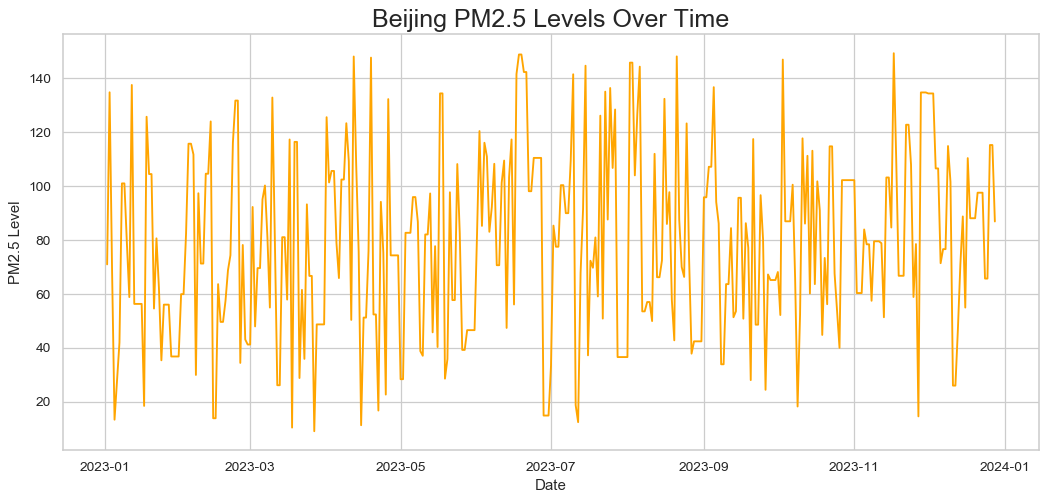

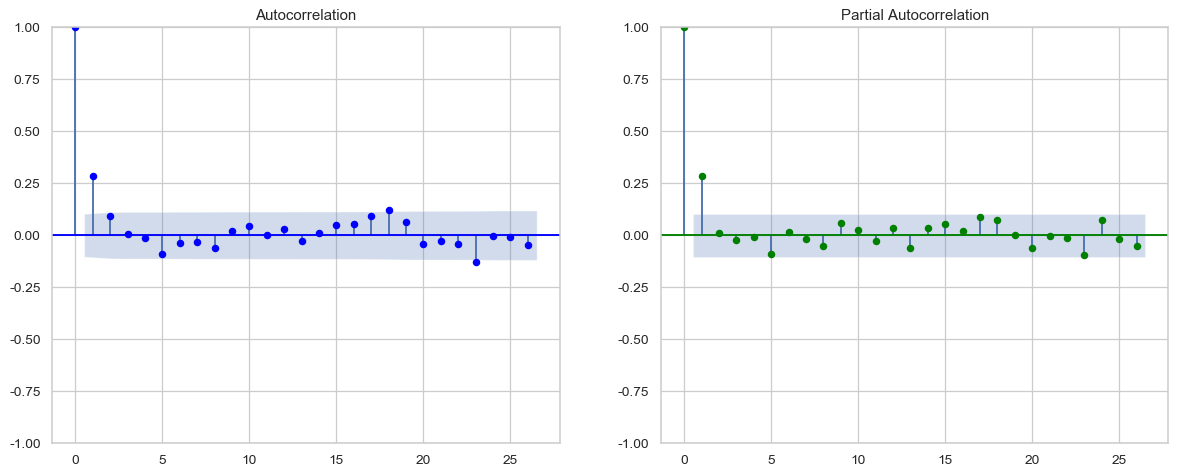

                               SARIMAX Results                                
Dep. Variable:                  PM2.5   No. Observations:                  261
Model:                 ARIMA(2, 0, 2)   Log Likelihood               -1287.475
Date:                Sat, 12 Sep 2026   AIC                           2586.951
Time:                        14:41:19   BIC                           2608.338
Sample:                    01-02-2023   HQIC                          2595.548
                         - 09-19-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         76.8016      2.976     25.806      0.000      70.968      82.635
ar.L1         -0.6075      0.375     -1.622      0.105      -1.342       0.127
ar.L2          0.0942      0.290      0.325      0.7

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/opt/anaconda3/lib/python3.13/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


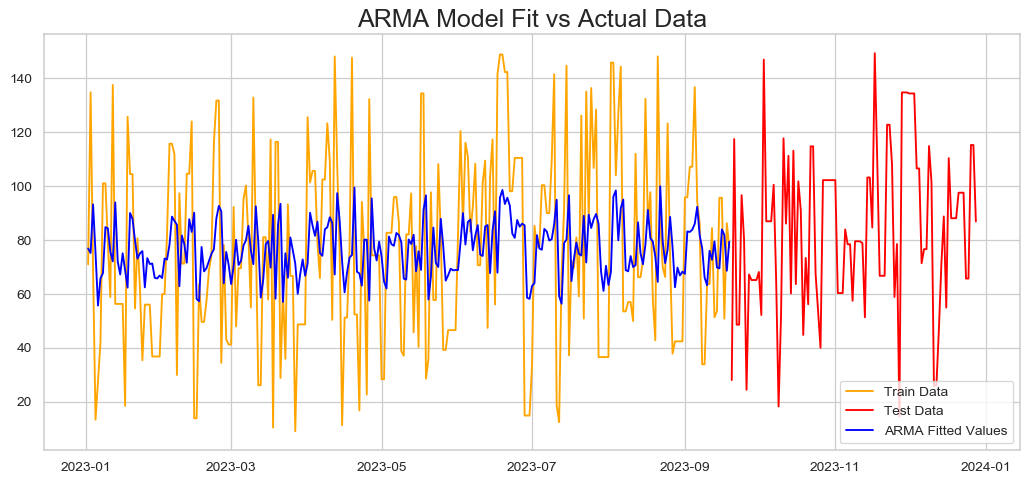

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objs as go
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error

# 设置图形风格
sns.set(style="whitegrid")
plt.rcParams['font.sans-serif'] = CJK_FONTS
# 加载Kaggle的全球空气质量数据集 (上述获取，选取北京的天气作为数据集)
data = pd.read_csv(DATA_DIR / 'global_air_quality_data_bj.csv')

# 将日期转换为DateTime格式，并设置为索引
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# 选择北京的数据和PM2.5指标
city_data = data[data['City'] == 'Beijing']
pm_data = city_data.groupby(level=0)['PM2.5'].mean().sort_index().asfreq('D').ffill().dropna()  # 用前向填充处理缺失值

# 绘制原始PM2.5数据时间序列图
plt.figure(figsize=(14, 6))
plt.plot(pm_data, color='orange')
plt.title("Beijing PM2.5 Levels Over Time", fontsize=20)
plt.xlabel("Date")
plt.ylabel("PM2.5 Level")
plt.show()

# 自相关和偏自相关图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_acf(pm_data, ax=axes[0], color='blue', title="Autocorrelation")
plot_pacf(pm_data, ax=axes[1], color='green', title="Partial Autocorrelation")
plt.show()

# 分割训练集和测试集
train_data = pm_data[:-100]
test_data = pm_data[-100:]

# 构建并拟合ARMA模型
model = ARIMA(train_data, order=(2, 0, 2))  # 使用ARMA(2,2)
arma_model = model.fit()

# 打印模型摘要
print(arma_model.summary())

# 模型拟合结果可视化
plt.figure(figsize=(14, 6))
plt.plot(train_data, label="Train Data", color='orange')
plt.plot(test_data, label="Test Data", color='red')
plt.plot(arma_model.fittedvalues, label="ARMA Fitted Values", color='blue')
plt.title("ARMA Model Fit vs Actual Data", fontsize=20)
plt.legend()
plt.show()

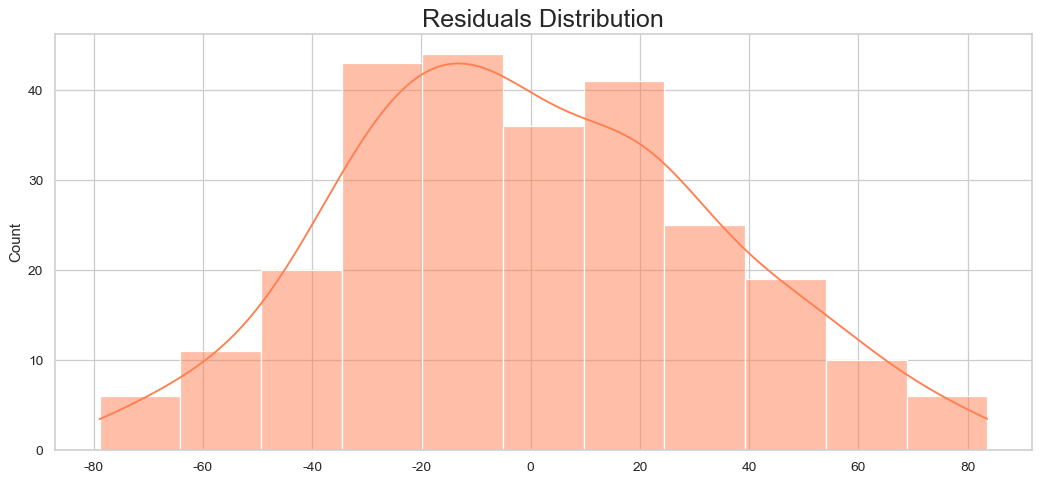

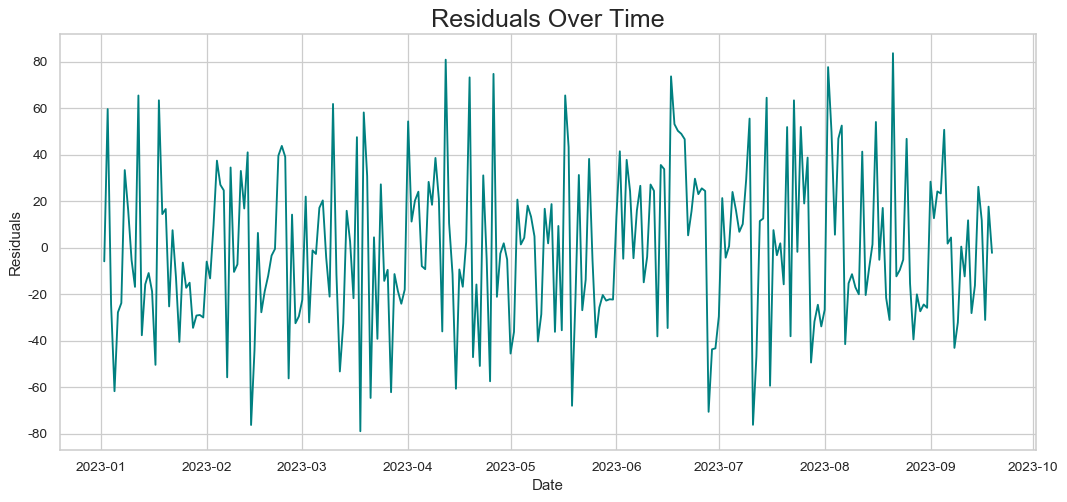

Mean Squared Error of Predictions: 918.89


In [3]:
# 预测未来100天的PM2.5数据
predictions = arma_model.get_forecast(steps=100)
pred_ci = predictions.conf_int()
predicted_pm = predictions.predicted_mean

# 使用Plotly绘制预测图形
fig = go.Figure()
fig.add_trace(go.Scatter(x=pm_data.index, y=pm_data, mode='lines', name='Actual PM2.5 Levels', line=dict(color='purple')))
fig.add_trace(go.Scatter(x=predicted_pm.index, y=predicted_pm, mode='lines', name='Forecasted PM2.5 Levels', line=dict(color='orange', dash='dash')))
fig.add_trace(go.Scatter(x=pred_ci.index, y=pred_ci.iloc[:, 0], fill=None, mode='lines', line=dict(color='lightblue'), name='Lower Confidence Interval'))
fig.add_trace(go.Scatter(x=pred_ci.index, y=pred_ci.iloc[:, 1], fill='tonexty', mode='lines', line=dict(color='lightblue'), name='Upper Confidence Interval'))
fig.update_layout(title="Beijing PM2.5 Levels Forecast with ARMA Model",
                  xaxis_title="Date",
                  yaxis_title="PM2.5 Level",
                  template="plotly_dark")
fig.show()

# 残差分析
residuals = arma_model.resid

# 绘制残差的直方图
plt.figure(figsize=(14, 6))
sns.histplot(residuals, kde=True, color='coral')
plt.title("Residuals Distribution", fontsize=20)
plt.show()

# 残差的时间序列图
plt.figure(figsize=(14, 6))
plt.plot(residuals, color='teal')
plt.title("Residuals Over Time", fontsize=20)
plt.xlabel("Date")
plt.ylabel("Residuals")
plt.show()

# 打印残差的均方误差
mse = mean_squared_error(test_data, predicted_pm[:len(test_data)])
print(f"Mean Squared Error of Predictions: {mse:.2f}")

1. **数据处理**：我们使用了「全球空气质量数据集」，选择北京的 PM2.5 作为分析指标，并将日期列设置为索引。数据中的缺失值通过前向填充（`fillna(method='ffill')`）的方式处理。
2. **时间序列可视化**：绘制了 PM2.5 的时间序列图，展示了北京空气质量随时间的变化。自相关函数（ACF）和偏自相关函数（PACF）图帮助我们确定 AR 和 MA 的阶数。
3. **ARMA 模型拟合与预测**：使用 `ARIMA` 模型的 ARMA(2,2) 进行拟合，并将拟合结果与原始数据进行比较。模型预测了未来 100 天的 PM2.5 数据，并使用 `Plotly` 进行交互式图表绘制，展示了预测值与置信区间。
4. **残差分析**：通过直方图和残差时间序列图分析残差分布，帮助我们评估模型拟合的质量。计算了模型预测的均方误差（MSE）来衡量预测的准确性。

#### 此代码生成的图形包括：

**PM2.5 原始数据的时间序列图**：展示空气质量的历史变化。

![原文参考图，当前结果见代码输出](attachments/img_017.png)

**自相关和偏自相关图**：用于帮助模型阶数的选择。

![原文参考图，当前结果见代码输出](attachments/img_018.png)

**拟合数据与实际数据对比图**：展示模型拟合效果。

![原文参考图，当前结果见代码输出](attachments/img_019.png)

**预测未来 PM2.5 数据的图表**：带有上下置信区间的预测曲线，使用 `Plotly` 绘制的交互式图形。

![原文参考图，当前结果见代码输出](attachments/img_020.png)

**残差分布与残差时间序列图**：用于分析模型的残差，判断模型的拟合效果。

![原文参考图，当前结果见代码输出](attachments/img_021.png)

![原文参考图，当前结果见代码输出](attachments/img_022.png)

## 优缺点和适用场景

### ARMA 模型优缺点

**优点**：

1. **简洁高效**：ARMA 模型使用较少的参数来描述时间序列，使得模型相对简洁。适用于平稳时间序列的分析和预测。
2. **灵活性高**：通过组合自回归（AR）和滑动平均（MA），ARMA 可以捕捉到序列中的自相关性和误差相关性，适应性较强。
3. **计算方便**：模型的构建和求解在统计软件中较为简单，且估计参数的计算较为高效。
4. **广泛应用**：适用于各种平稳时间序列的分析，如股票价格、经济指标、气象数据等。

**缺点**：

1. **仅适用于平稳数据**：ARMA 只能处理平稳时间序列（数据的均值和方差不随时间变化），对于非平稳序列，需要先对数据进行差分等平稳化处理。
2. **参数选择复杂**：确定模型的阶数 $p$ 和 $q$ 通常需要借助 ACF、PACF 图，以及反复试验，难以自动化。
3. **对长记忆序列无效**：如果数据中存在长记忆性（即长期相关性），ARMA 模型通常效果不佳。这种情况可能需要更复杂的模型（如 ARIMA、ARFIMA）。
4. **无法捕捉非线性关系**：ARMA 是线性模型，对于非线性特征较强的数据，模型表现一般。

### ARMA 模型适用场景

ARMA 模型适用于以下场景：

- **经济和金融数据**：比如股市价格、利率、汇率等时间序列。因为这些数据往往具备平稳性，短期内没有明显的趋势。
- **生产和制造数据**：例如机器的传感器数据、生产线的产量等，这些数据一般是平稳的且存在一定的周期或季节性。
- **气象和环境数据**：气温、降雨量等时间序列，通常可以通过平稳化处理（例如去掉趋势）使用 ARMA 模型进行短期预测。
- **人口统计数据**：如日常人流量、出生率等相对平稳的序列，可以利用 ARMA 模型进行短期的波动分析。

### 移动平均方法及其应用场景

移动平均（MA）是一种基础的时间序列平滑处理方法，常用于去噪、发现趋势等。MA 将一段时间内的数据取平均，用这个平均值来代表这一段时间的趋势，常见的类型有简单移动平均（SMA）、加权移动平均（WMA）、指数移动平均（EMA）等。

### 常见的移动平均案例

1. **股票市场分析**：移动平均广泛应用于股票市场，尤其是 **简单移动平均**（SMA）和 **指数移动平均**（EMA）。交易者常用 MA 来识别趋势，或结合多个移动平均线作为买入卖出的信号。例如，交叉策略即是指短期移动平均线与长期移动平均线的交叉点作为买入或卖出信号。
2. **销售数据平滑和趋势识别**：对于销售数据，可以使用移动平均法消除短期波动，从而更好地识别总体趋势。例如，分析商品的月度销量，可以用 3 个月的 SMA 来平滑数据，识别季节性趋势。
3. **需求预测与库存管理**：移动平均常用于预测库存需求。例如，企业可以使用移动平均预测未来一段时间的需求量，以此调整库存。这样能够应对日常波动带来的不确定性，优化库存管理。
4. **气象数据趋势分析**：在气象分析中，移动平均法用于分析温度、降水量等数据的变化趋势。例如，使用 7 天移动平均来平滑每日温度数据，从而更清晰地观察出温度的变化趋势。
5. **交通流量管理**：对交通流量数据进行移动平均处理，可以更好地分析拥堵模式和趋势。例如，使用 5 分钟或 10 分钟的移动平均平滑化每分钟流量数据，以识别高峰和低谷。

## 总结

整个理论解释和案例展示了如何使用空气质量数据进行时间序列分析，通过 ARMA 模型对 PM2.5 数据进行建模、预测，并通过复杂的图形进行可视化。这种方法不仅适用于空气质量数据，还可以应用于类似的环境数据、能源数据等时间序列分析场景。